Cargando artefactos base...

Evaluando A3T-GCN h1...

Evaluando DCRNN h1...

Evaluando DCRNN h6...

Evaluando DCRNN h12...

Evaluando DCRNN h24...

TABLA CONSOLIDADA (TEST)
    Modelo  Horizonte  MAE (°C)  RMSE (°C)     R²
A3T-GCN h1          1    0.5251     0.7522 0.9544
  DCRNN h1          1    0.3906     0.5781 0.9731
  DCRNN h6          6    0.6791     0.9921 0.9207
 DCRNN h12         12    0.7870     1.1118 0.9005
 DCRNN h24         24    0.8721     1.2148 0.8812

MÉTRICAS POR ESTACIÓN (TEST, h1)

MAE (°C):
Modelo      A3T-GCN h1  DCRNN h1
estacion                        
Belisario       0.5495    0.3932
Carapungo       0.5074    0.3808
Cotocollao      0.4999    0.3799
ElCamal         0.5612    0.3784
LosChillos      0.5347    0.4243
Tumbaco         0.5142    0.3819

R²:
Modelo      A3T-GCN h1  DCRNN h1
estacion                        
Belisario       0.9398    0.9664
Carapungo       0.9505    0.9701
Cotocollao      0.9439    0.9642
ElCamal         0.9083    0.9573
LosChillos     

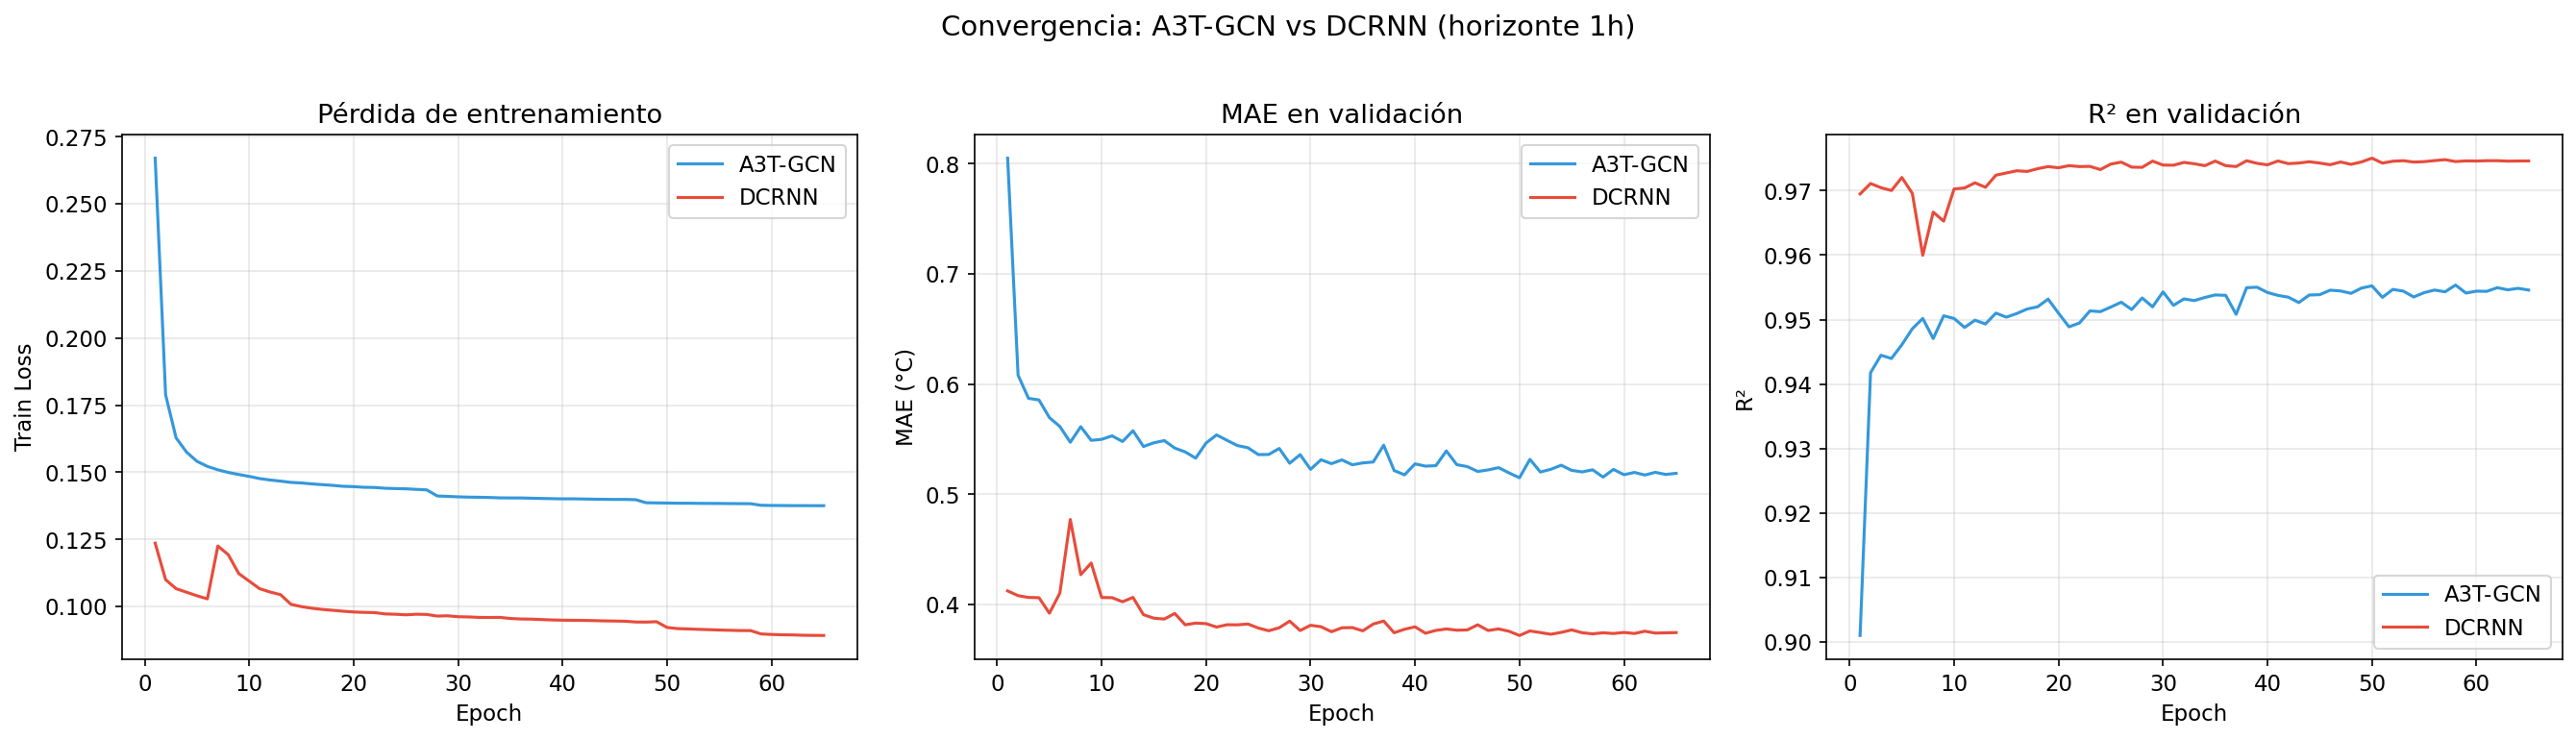

Guardado: convergencia_h1.png


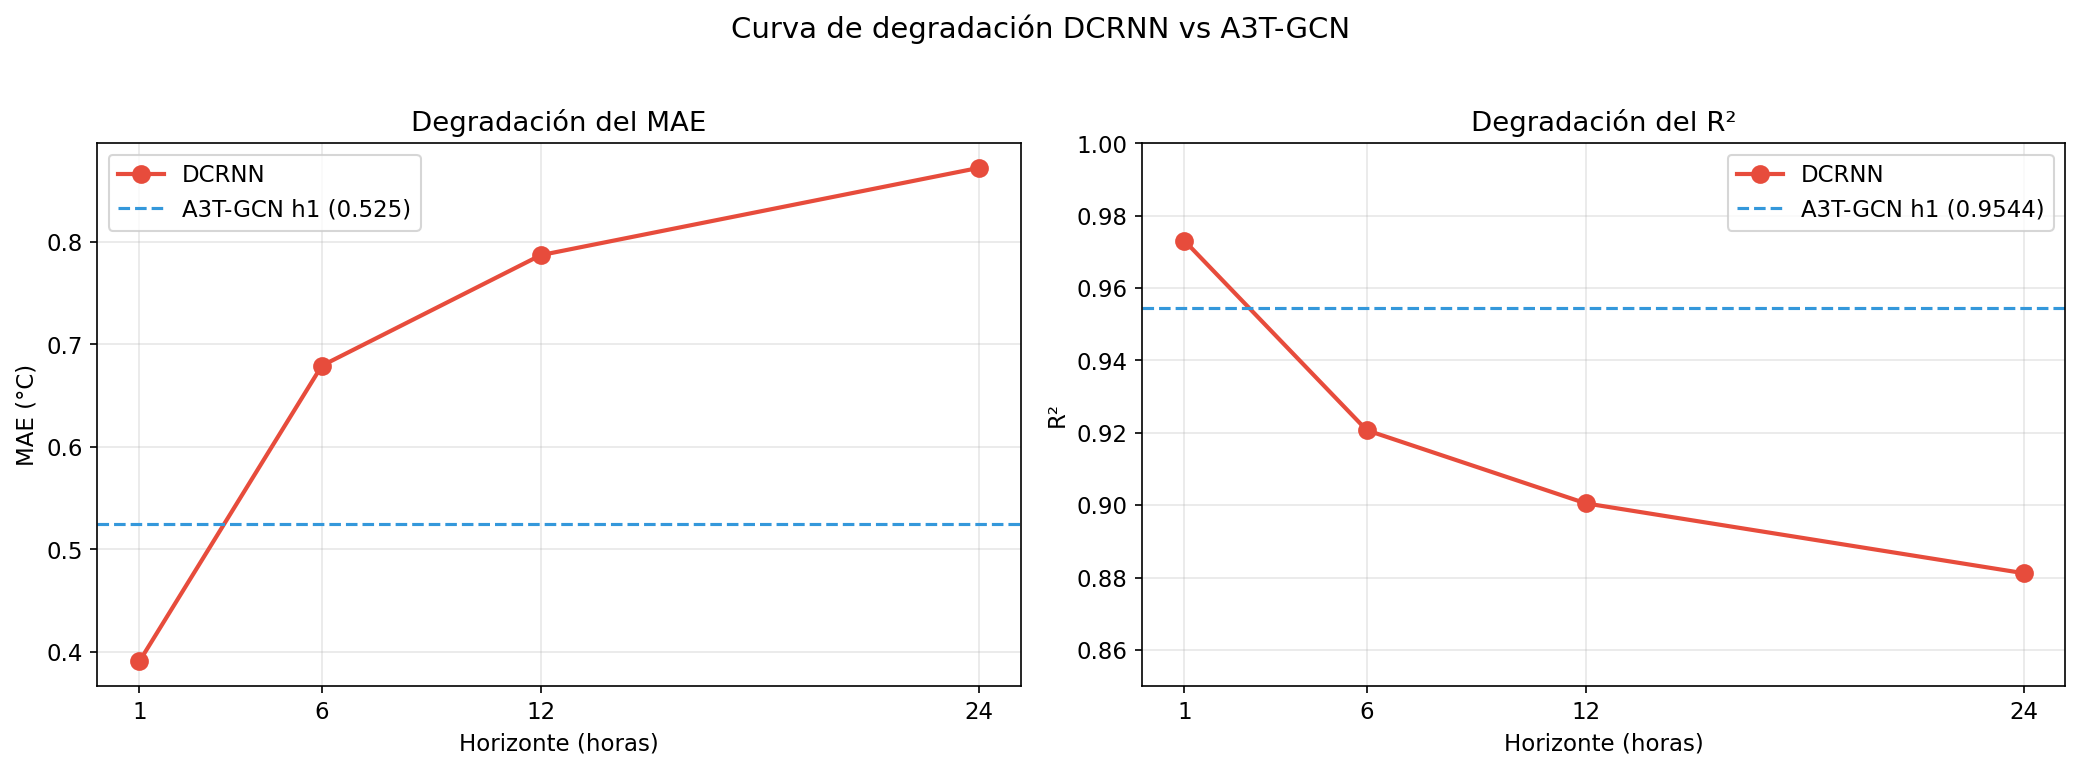

Guardado: degradacion_horizonte.png


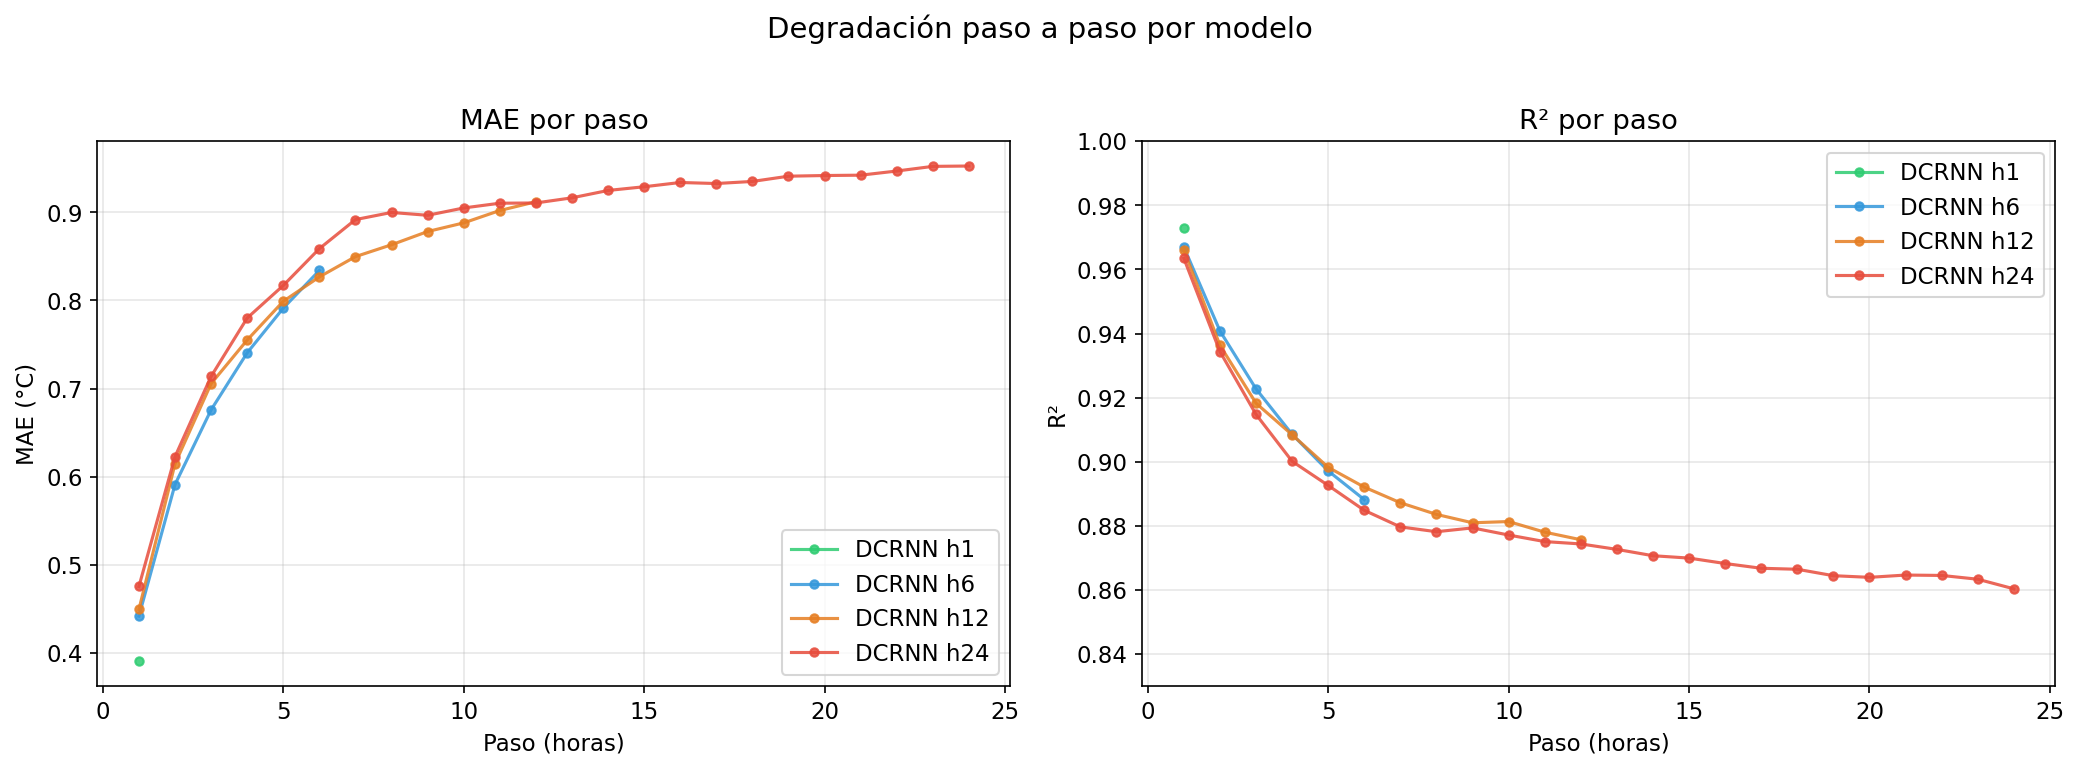

Guardado: degradacion_por_paso.png


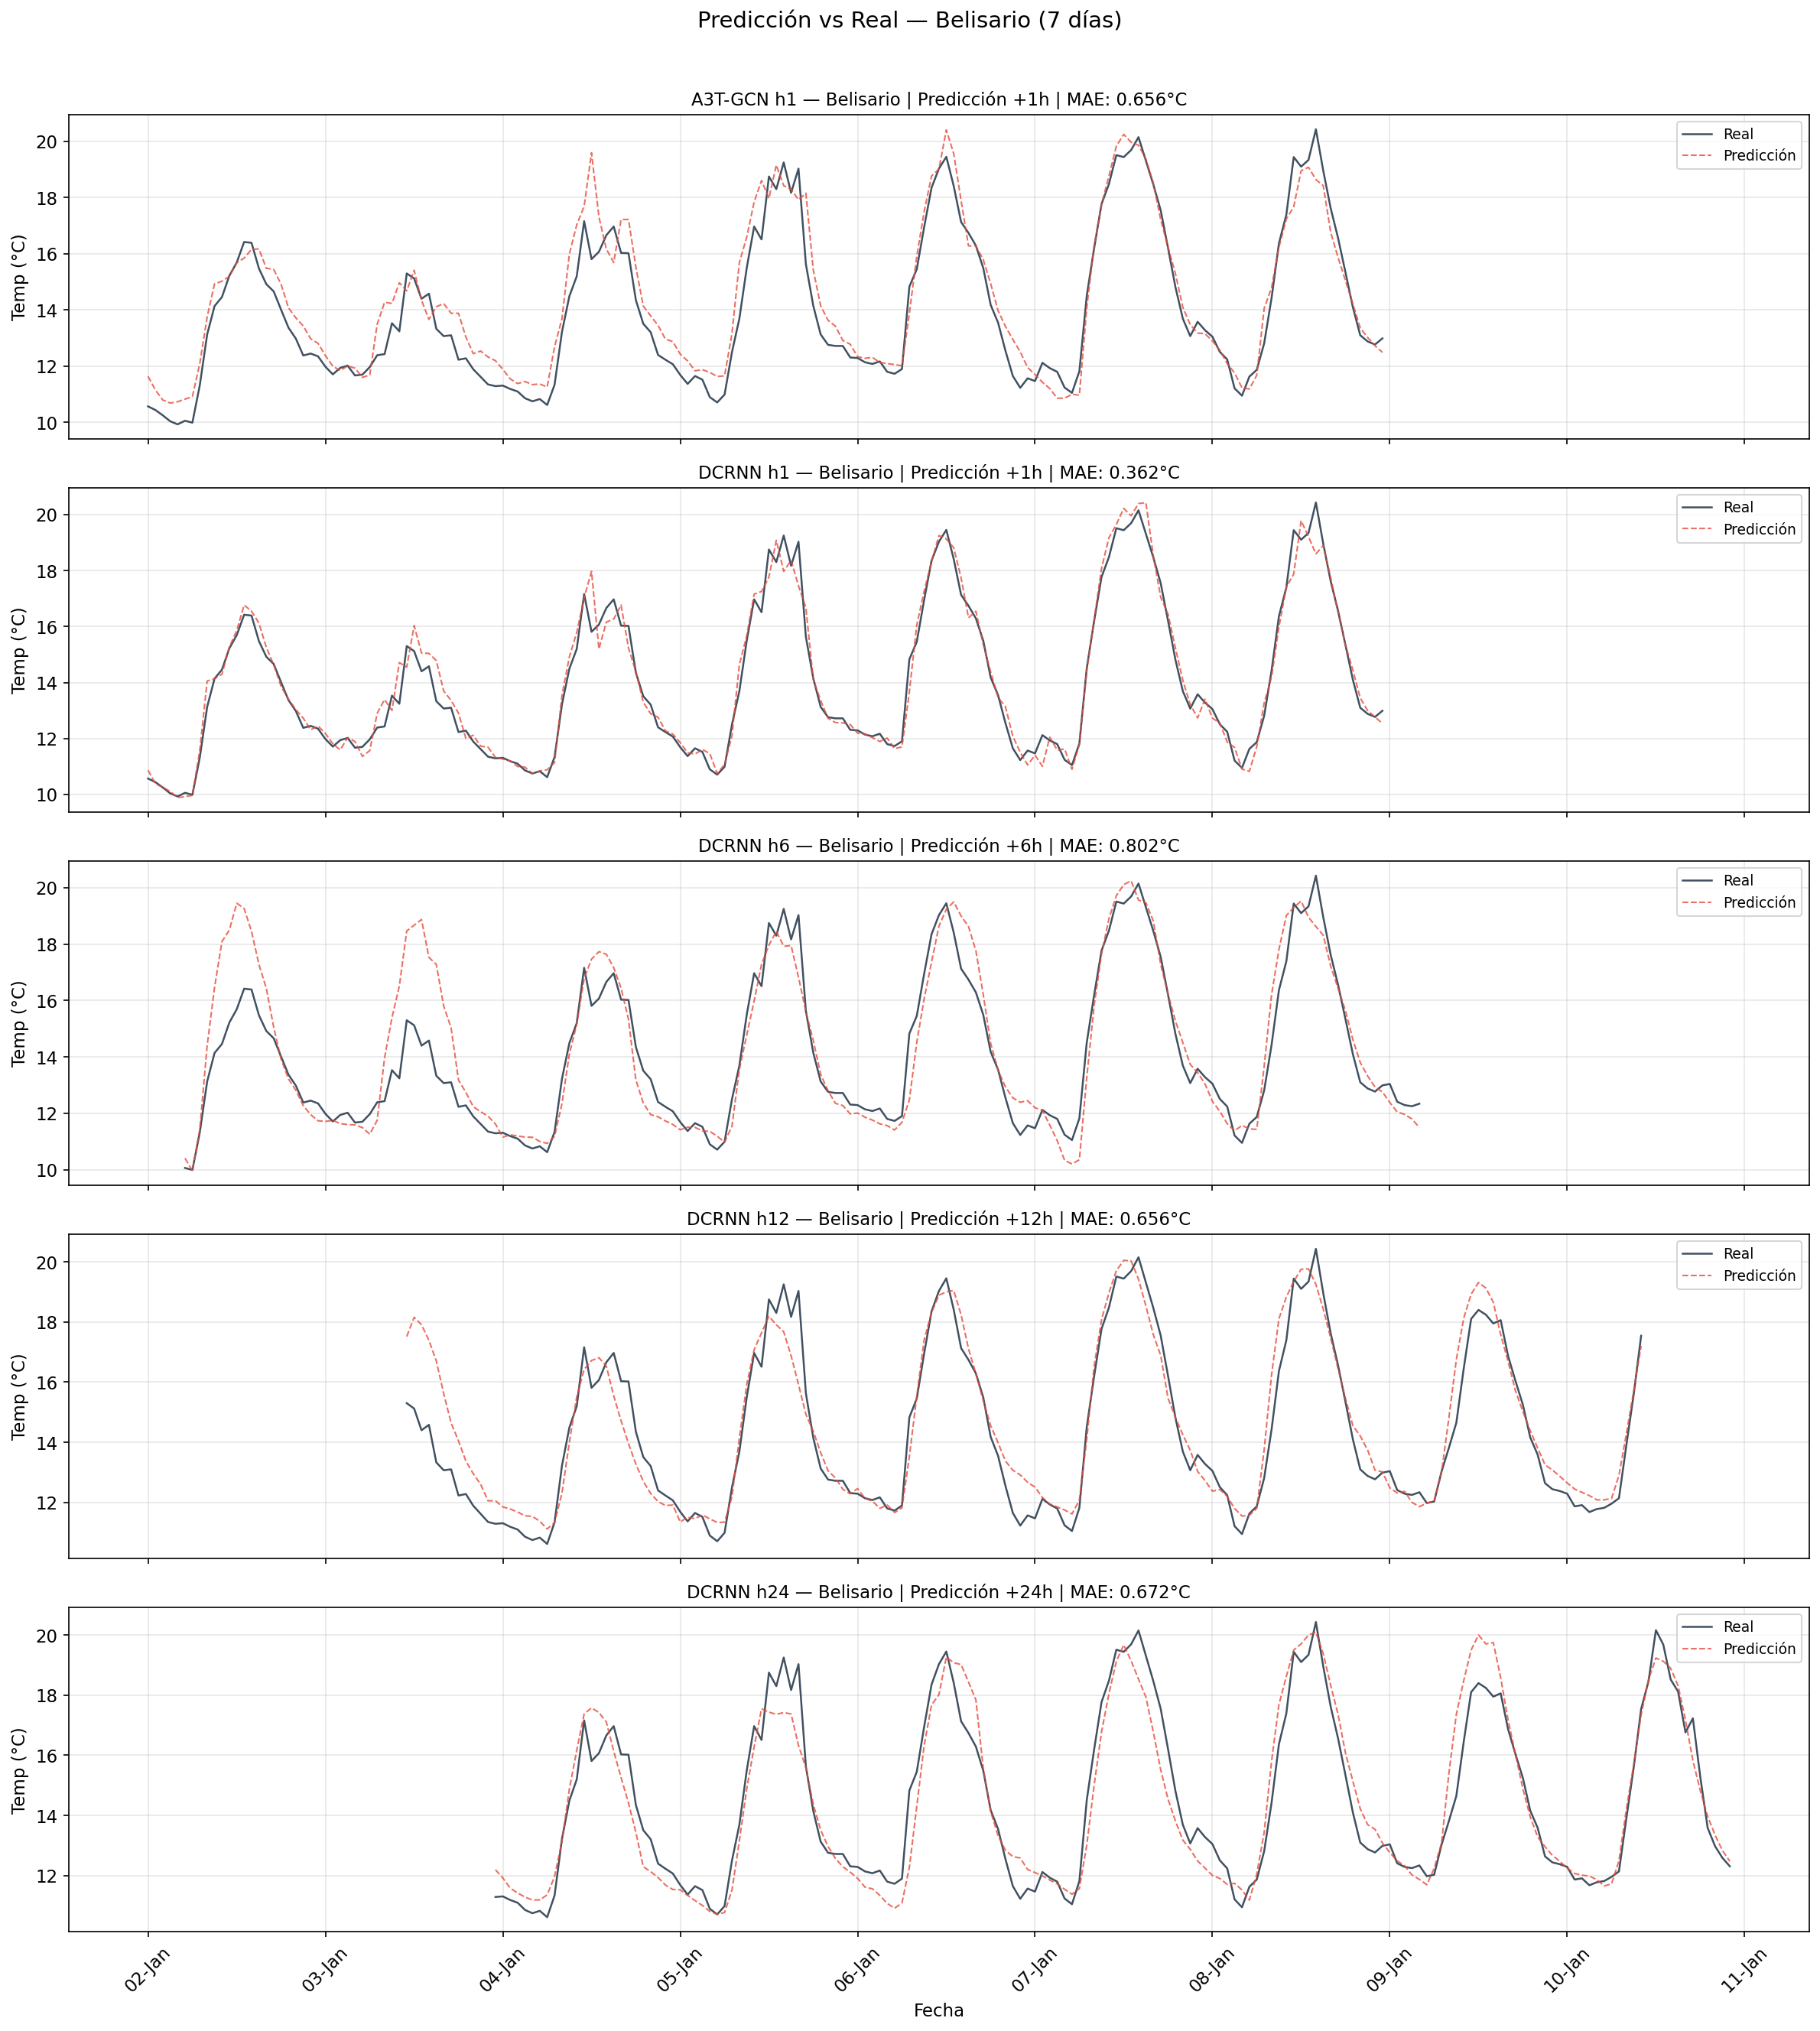

Guardado: prediccion_multi_Belisario_7d.png


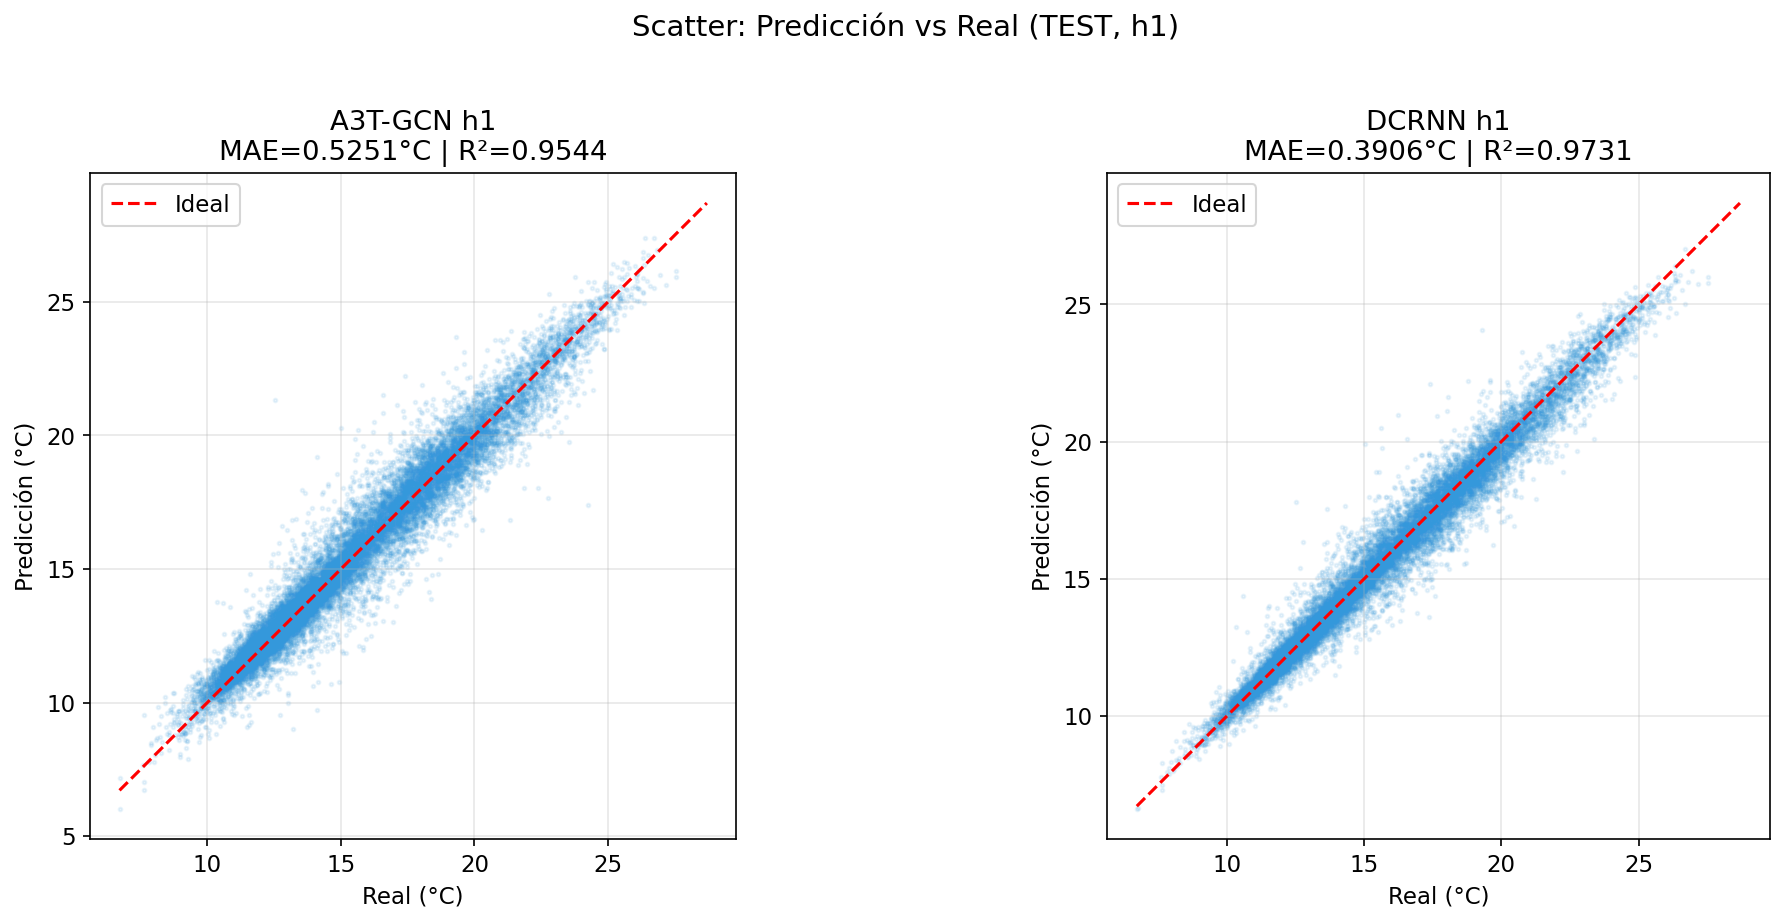

Guardado: scatter_pred_vs_real.png


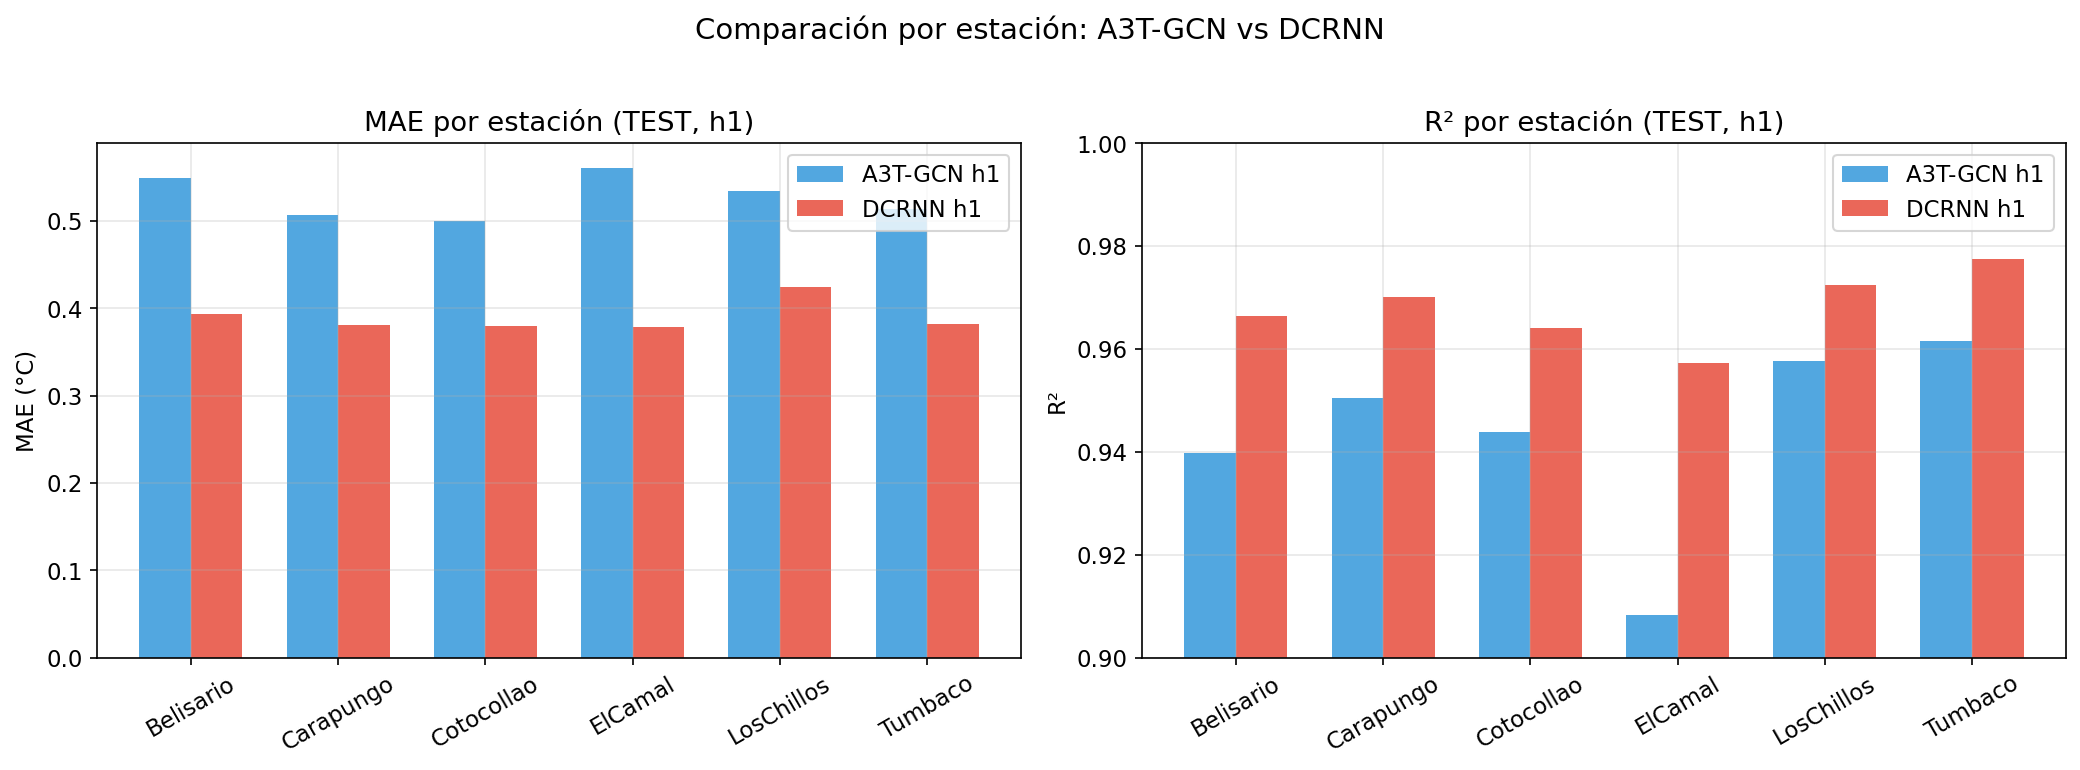

Guardado: error_por_estacion.png

ARCHIVOS GENERADOS:
  metricas_consolidadas.csv
  metricas_por_estacion.csv
  degradacion_pasos_DCRNN_h*.csv
  convergencia_h1.png
  degradacion_horizonte.png
  degradacion_por_paso.png
  prediccion_multi_Belisario_7d.png
  scatter_pred_vs_real.png
  error_por_estacion.png


In [1]:
"""
Evaluación comparativa completa - REMMAQ
Modelos: A3T-GCN (h1), DCRNN (h1, h6, h12, h24)
  1. Tabla consolidada de métricas por modelo y horizonte
  2. Métricas por estación (test)
  3. Curvas de convergencia A3T-GCN vs DCRNN (h1)
  4. Curva de degradación MAE/R² vs horizonte
  5. Degradación paso a paso (todos los horizontes superpuestos)
  6. Predicción vs real por horizonte
  7. Scatter plot
  8. Error por estación
"""

import numpy as np
import pandas as pd
import pickle
import torch
import torch.nn as nn
from torch.cuda.amp import autocast
from torch.utils.data import Dataset, DataLoader
from torch_geometric_temporal.nn.recurrent import A3TGCN, DCRNN
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
    "savefig.dpi": 150
})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STATIONS = ["Belisario", "Carapungo", "Cotocollao", "ElCamal", "LosChillos", "Tumbaco"]


# ============================================================
# DATASET Y BATCHING
# ============================================================
class STGNNDataset(Dataset):
    def __init__(self, data, mask, seq_len, horizon, target_idx):
        self.data = data; self.mask = mask
        self.seq_len = seq_len; self.horizon = horizon
        self.target_idx = target_idx
        self.n_samples = data.shape[0] - seq_len - horizon + 1
    def __len__(self): return self.n_samples
    def __getitem__(self, i):
        X = self.data[i:i+self.seq_len]
        y = self.data[i+self.seq_len:i+self.seq_len+self.horizon, :, self.target_idx]
        m = self.mask[i+self.seq_len:i+self.seq_len+self.horizon, :, self.target_idx]
        return (torch.tensor(X, dtype=torch.float32),
                torch.tensor(y, dtype=torch.float32),
                torch.tensor(m, dtype=torch.float32))

def batch_edge_index(ei, bs, n):
    return torch.cat([ei + i * n for i in range(bs)], dim=1)

def batch_edge_weight(ew, bs):
    return ew.repeat(bs)


# ============================================================
# MODELOS
# ============================================================
class A3TGCNForecaster(nn.Module):
    def __init__(self, in_channels, hidden, horizon, periods):
        super().__init__()
        self.tgnn = A3TGCN(in_channels=in_channels, out_channels=hidden, periods=periods)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x, edge_index, edge_weight):
        return self.head(self.tgnn(x, edge_index, edge_weight))

class DCRNNForecaster(nn.Module):
    def __init__(self, in_channels, hidden, horizon, K=2):
        super().__init__()
        self.dcrnn = DCRNN(in_channels=in_channels, out_channels=hidden, K=K)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x_seq, edge_index, edge_weight):
        h = None
        for t in range(x_seq.size(0)):
            h = self.dcrnn(x_seq[t], edge_index, edge_weight, H=h)
        return self.head(h)


# ============================================================
# PREDICCIÓN
# ============================================================
@torch.no_grad()
def predict_all(model, model_type, loader, edge_index, edge_weight, n_nodes):
    model.eval()
    all_pred, all_target, all_mask = [], [], []
    for X, y, m in loader:
        bs = X.size(0)
        X = X.to(DEVICE)
        ei = batch_edge_index(edge_index, bs, n_nodes).to(DEVICE)
        ew = batch_edge_weight(edge_weight, bs).to(DEVICE)
        with autocast():
            if model_type == "a3tgcn":
                x_in = X.permute(0, 2, 3, 1).reshape(bs * n_nodes, -1, X.size(1))
            else:
                x_in = X.permute(1, 0, 2, 3).reshape(X.size(1), bs * n_nodes, -1)
            out = model(x_in, ei, ew)
            out = out.reshape(bs, n_nodes, -1).permute(0, 2, 1)
        all_pred.append(out.cpu().numpy())
        all_target.append(y.numpy())
        all_mask.append(m.numpy())
    return np.concatenate(all_pred), np.concatenate(all_target), np.concatenate(all_mask)


def metrics_global(pred, target, mask, sc):
    p = sc.inverse_transform(pred.flatten().reshape(-1, 1)).flatten()
    t = sc.inverse_transform(target.flatten().reshape(-1, 1)).flatten()
    m = mask.flatten().astype(bool)
    p, t = p[m], t[m]
    mae = np.mean(np.abs(t - p))
    rmse = np.sqrt(np.mean((t - p) ** 2))
    r2 = 1 - np.sum((t - p)**2) / np.sum((t - t.mean())**2)
    return {"MAE": mae, "RMSE": rmse, "R2": r2}


def metrics_per_station(pred, target, mask, sc):
    results = []
    for i, st in enumerate(STATIONS):
        p = sc.inverse_transform(pred[:, :, i].flatten().reshape(-1, 1)).flatten()
        t = sc.inverse_transform(target[:, :, i].flatten().reshape(-1, 1)).flatten()
        m = mask[:, :, i].flatten().astype(bool)
        if m.sum() == 0: continue
        p, t = p[m], t[m]
        mae = np.mean(np.abs(t - p))
        rmse = np.sqrt(np.mean((t - p)**2))
        r2 = 1 - np.sum((t - p)**2) / np.sum((t - t.mean())**2)
        results.append({"estacion": st, "MAE": mae, "RMSE": rmse, "R2": r2})
    return pd.DataFrame(results)


def metrics_per_step(pred, target, mask, sc, horizon):
    results = []
    for h in range(horizon):
        p = sc.inverse_transform(pred[:, h, :].flatten().reshape(-1, 1)).flatten()
        t = sc.inverse_transform(target[:, h, :].flatten().reshape(-1, 1)).flatten()
        m = mask[:, h, :].flatten().astype(bool)
        p, t = p[m], t[m]
        mae = np.mean(np.abs(t - p))
        rmse = np.sqrt(np.mean((t - p)**2))
        r2 = 1 - np.sum((t - p)**2) / np.sum((t - t.mean())**2)
        results.append({"step": h+1, "MAE": mae, "RMSE": rmse, "R2": r2})
    return pd.DataFrame(results)


# ============================================================
# CONFIGURACIÓN DE MODELOS
# ============================================================
MODELS_CONFIG = [
    {"nombre": "A3T-GCN h1",  "tipo": "a3tgcn", "horizon": 1,  "seq_len": 24,
     "archivo": "best_model.pt", "hist": "training_history.csv"},
    {"nombre": "DCRNN h1",    "tipo": "dcrnn",   "horizon": 1,  "seq_len": 24,
     "archivo": "best_model_dcrnn.pt", "hist": "training_history_dcrnn.csv"},
    {"nombre": "DCRNN h6",    "tipo": "dcrnn",   "horizon": 6,  "seq_len": 24,
     "archivo": "best_model_dcrnn_h6.pt", "hist": "training_history_dcrnn_h6.csv"},
    {"nombre": "DCRNN h12",   "tipo": "dcrnn",   "horizon": 12, "seq_len": 48,
     "archivo": "best_model_dcrnn_h12.pt", "hist": "training_history_dcrnn_h12.csv"},
    {"nombre": "DCRNN h24",   "tipo": "dcrnn",   "horizon": 24, "seq_len": 48,
     "archivo": "best_model_dcrnn_h24.pt", "hist": "training_history_dcrnn_h24.csv"},
]

def cargar_modelo(cfg):
    if cfg["tipo"] == "a3tgcn":
        model = A3TGCNForecaster(14, 64, cfg["horizon"], cfg["seq_len"])
    else:
        model = DCRNNForecaster(14, 64, cfg["horizon"], K=2)
    model.load_state_dict(torch.load(cfg["archivo"], map_location=DEVICE))
    model.to(DEVICE); model.eval()
    return model

def crear_loader(split_data, split_mask, seq_len, horizon, target_idx=6):
    ds = STGNNDataset(split_data, split_mask, seq_len, horizon, target_idx)
    return DataLoader(ds, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)


# ============================================================
# GRÁFICOS
# ============================================================
def graficar_convergencia():
    hist_a3t = pd.read_csv("training_history.csv")
    hist_dcrnn = pd.read_csv("training_history_dcrnn.csv")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for nombre, h, color in [("A3T-GCN", hist_a3t, "#3498db"), ("DCRNN", hist_dcrnn, "#e74c3c")]:
        axes[0].plot(h["epoch"], h["train_loss"], label=nombre, color=color, lw=1.5)
        axes[1].plot(h["epoch"], h["val_MAE_C"], label=nombre, color=color, lw=1.5)
        axes[2].plot(h["epoch"], h["val_R2"], label=nombre, color=color, lw=1.5)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Train Loss"); axes[0].set_title("Pérdida de entrenamiento"); axes[0].legend()
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE (°C)"); axes[1].set_title("MAE en validación"); axes[1].legend()
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("R²"); axes[2].set_title("R² en validación"); axes[2].legend()
    plt.suptitle("Convergencia: A3T-GCN vs DCRNN (horizonte 1h)", fontsize=14, y=1.02)
    plt.tight_layout(); plt.savefig("convergencia_h1.png"); plt.show()
    print("Guardado: convergencia_h1.png")


def graficar_degradacion(df_con):
    df_dcrnn = df_con[df_con["Modelo"].str.startswith("DCRNN")]
    df_a3t = df_con[df_con["Modelo"] == "A3T-GCN h1"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(df_dcrnn["Horizonte"], df_dcrnn["MAE (°C)"], "o-", color="#e74c3c", lw=2, ms=8, label="DCRNN")
    axes[0].axhline(y=df_a3t["MAE (°C)"].values[0], color="#3498db", ls="--", lw=1.5,
                    label=f"A3T-GCN h1 ({df_a3t['MAE (°C)'].values[0]:.3f})")
    axes[0].set_xlabel("Horizonte (horas)"); axes[0].set_ylabel("MAE (°C)")
    axes[0].set_title("Degradación del MAE"); axes[0].set_xticks([1, 6, 12, 24]); axes[0].legend()

    axes[1].plot(df_dcrnn["Horizonte"], df_dcrnn["R²"], "o-", color="#e74c3c", lw=2, ms=8, label="DCRNN")
    axes[1].axhline(y=df_a3t["R²"].values[0], color="#3498db", ls="--", lw=1.5,
                    label=f"A3T-GCN h1 ({df_a3t['R²'].values[0]:.4f})")
    axes[1].set_xlabel("Horizonte (horas)"); axes[1].set_ylabel("R²")
    axes[1].set_title("Degradación del R²"); axes[1].set_xticks([1, 6, 12, 24])
    axes[1].set_ylim(0.85, 1.0); axes[1].legend()

    plt.suptitle("Curva de degradación DCRNN vs A3T-GCN", fontsize=14, y=1.02)
    plt.tight_layout(); plt.savefig("degradacion_horizonte.png"); plt.show()
    print("Guardado: degradacion_horizonte.png")


def graficar_degradacion_por_paso(step_results):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = {"DCRNN h1": "#2ecc71", "DCRNN h6": "#3498db", "DCRNN h12": "#e67e22", "DCRNN h24": "#e74c3c"}
    for nombre, df_s in step_results.items():
        c = colors.get(nombre, "#333")
        axes[0].plot(df_s["step"], df_s["MAE"], "o-", color=c, lw=1.5, ms=4, label=nombre, alpha=0.85)
        axes[1].plot(df_s["step"], df_s["R2"], "o-", color=c, lw=1.5, ms=4, label=nombre, alpha=0.85)
    axes[0].set_xlabel("Paso (horas)"); axes[0].set_ylabel("MAE (°C)"); axes[0].set_title("MAE por paso"); axes[0].legend()
    axes[1].set_xlabel("Paso (horas)"); axes[1].set_ylabel("R²"); axes[1].set_title("R² por paso")
    axes[1].set_ylim(0.83, 1.0); axes[1].legend()
    plt.suptitle("Degradación paso a paso por modelo", fontsize=14, y=1.02)
    plt.tight_layout(); plt.savefig("degradacion_por_paso.png"); plt.show()
    print("Guardado: degradacion_por_paso.png")


def graficar_prediccion_multi(predictions, idx_test, estacion_idx=0, dias=7):
    estacion = STATIONS[estacion_idx]
    horas = dias * 24
    n_plots = len(predictions)
    fig, axes = plt.subplots(n_plots, 1, figsize=(16, 3.5 * n_plots), sharex=True)
    if n_plots == 1: axes = [axes]

    for ax, (nombre, pred, target, mask, seq_len, horizon) in zip(axes, predictions):
        step_plot = horizon - 1
        t_real = target[:horas, step_plot, estacion_idx]
        t_pred = pred[:horas, step_plot, estacion_idx]
        m = mask[:horas, step_plot, estacion_idx].astype(bool)
        fechas = idx_test[seq_len + step_plot:seq_len + step_plot + horas]
        n = min(horas, len(fechas), len(t_real))
        t_real, t_pred, m, fechas = t_real[:n], t_pred[:n], m[:n], fechas[:n]

        ax.plot(fechas, t_real, color="#2c3e50", lw=1.2, label="Real", alpha=0.9)
        ax.plot(fechas, np.where(m, t_pred, np.nan), color="#e74c3c", lw=1.0, label="Predicción", alpha=0.8, ls="--")
        mae_v = np.mean(np.abs(t_real[m] - t_pred[m])) if m.sum() > 0 else 0
        ax.set_title(f"{nombre} — {estacion} | Predicción +{horizon}h | MAE: {mae_v:.3f}°C", fontsize=11)
        ax.set_ylabel("Temp (°C)"); ax.legend(loc="upper right", fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b")); ax.xaxis.set_major_locator(mdates.DayLocator())

    plt.xlabel("Fecha"); plt.xticks(rotation=45)
    plt.suptitle(f"Predicción vs Real — {estacion} ({dias} días)", fontsize=14, y=1.01)
    plt.tight_layout(); plt.savefig(f"prediccion_multi_{estacion}_{dias}d.png"); plt.show()
    print(f"Guardado: prediccion_multi_{estacion}_{dias}d.png")


def graficar_scatter(scatter_data):
    n = len(scatter_data)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1: axes = [axes]
    for ax, (nombre, p, t) in zip(axes, scatter_data):
        if len(p) > 20000:
            idx = np.random.RandomState(42).choice(len(p), 20000, replace=False)
            p_s, t_s = p[idx], t[idx]
        else: p_s, t_s = p, t
        ax.scatter(t_s, p_s, alpha=0.1, s=3, color="#3498db")
        ax.plot([t.min(), t.max()], [t.min(), t.max()], "r--", lw=1.5, label="Ideal")
        mae = np.mean(np.abs(t - p)); r2 = 1 - np.sum((t-p)**2)/np.sum((t-t.mean())**2)
        ax.set_xlabel("Real (°C)"); ax.set_ylabel("Predicción (°C)")
        ax.set_title(f"{nombre}\nMAE={mae:.4f}°C | R²={r2:.4f}"); ax.legend()
        ax.set_aspect("equal", adjustable="box")
    plt.suptitle("Scatter: Predicción vs Real (TEST, h1)", fontsize=14, y=1.02)
    plt.tight_layout(); plt.savefig("scatter_pred_vs_real.png"); plt.show()
    print("Guardado: scatter_pred_vs_real.png")


def graficar_error_estacion(df_est):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    modelos = df_est["Modelo"].unique()
    x = np.arange(len(STATIONS)); width = 0.35; colors = ["#3498db", "#e74c3c"]
    for i, nombre in enumerate(modelos):
        sub = df_est[df_est["Modelo"] == nombre].set_index("estacion").reindex(STATIONS)
        axes[0].bar(x + i*width, sub["MAE"], width, label=nombre, color=colors[i], alpha=0.85)
        axes[1].bar(x + i*width, sub["R2"], width, label=nombre, color=colors[i], alpha=0.85)
    axes[0].set_xticks(x+width/2); axes[0].set_xticklabels(STATIONS, rotation=30)
    axes[0].set_ylabel("MAE (°C)"); axes[0].set_title("MAE por estación (TEST, h1)"); axes[0].legend()
    axes[1].set_xticks(x+width/2); axes[1].set_xticklabels(STATIONS, rotation=30)
    axes[1].set_ylabel("R²"); axes[1].set_title("R² por estación (TEST, h1)"); axes[1].legend()
    axes[1].set_ylim(0.90, 1.0)
    plt.suptitle("Comparación por estación: A3T-GCN vs DCRNN", fontsize=14, y=1.02)
    plt.tight_layout(); plt.savefig("error_por_estacion.png"); plt.show()
    print("Guardado: error_por_estacion.png")


# ============================================================
# EJECUCIÓN
# ============================================================
if __name__ == "__main__":
    print("Cargando artefactos base...")
    edge_index = torch.load("edge_index.pt")
    edge_weight = torch.load("edge_weight.pt")
    with open("scalers.pkl", "rb") as f:
        scalers = pickle.load(f)
    sc = scalers[6]
    idx_temporal = pd.DatetimeIndex(np.load("idx_temporal.npy"))
    idx_test = idx_temporal[idx_temporal >= "2024-01-01"]

    splits_data, splits_mask = {}, {}
    for split in ["train", "val", "test"]:
        splits_data[split] = np.load(f"tensor_{split}.npy")
        splits_mask[split] = np.load(f"mask_{split}.npy")

    resultados_globales = []
    est_results_h1 = []
    step_results = {}
    scatter_data = []
    prediction_data = []

    for cfg in MODELS_CONFIG:
        print(f"\nEvaluando {cfg['nombre']}...")
        model = cargar_modelo(cfg)
        loader_test = crear_loader(splits_data["test"], splits_mask["test"], cfg["seq_len"], cfg["horizon"])
        pred, target, mask = predict_all(model, cfg["tipo"], loader_test, edge_index, edge_weight, 6)

        m_g = metrics_global(pred, target, mask, sc)
        resultados_globales.append({
            "Modelo": cfg["nombre"], "Horizonte": cfg["horizon"],
            "MAE (°C)": round(m_g["MAE"], 4), "RMSE (°C)": round(m_g["RMSE"], 4), "R²": round(m_g["R2"], 4),
        })

        if cfg["horizon"] == 1:
            df_st = metrics_per_station(pred, target, mask, sc)
            df_st["Modelo"] = cfg["nombre"]
            est_results_h1.append(df_st)
            p_f = sc.inverse_transform(pred.flatten().reshape(-1,1)).flatten()
            t_f = sc.inverse_transform(target.flatten().reshape(-1,1)).flatten()
            m_f = mask.flatten().astype(bool)
            scatter_data.append((cfg["nombre"], p_f[m_f], t_f[m_f]))

        if cfg["tipo"] == "dcrnn":
            step_results[cfg["nombre"]] = metrics_per_step(pred, target, mask, sc, cfg["horizon"])

        pred_r = sc.inverse_transform(pred.flatten().reshape(-1,1)).reshape(pred.shape)
        target_r = sc.inverse_transform(target.flatten().reshape(-1,1)).reshape(target.shape)
        prediction_data.append((cfg["nombre"], pred_r, target_r, mask, cfg["seq_len"], cfg["horizon"]))

    # Generar todo
    print("\n" + "="*80)
    print("TABLA CONSOLIDADA (TEST)")
    print("="*80)
    df_con = pd.DataFrame(resultados_globales)
    print(df_con.to_string(index=False))

    print("\n" + "="*80)
    print("MÉTRICAS POR ESTACIÓN (TEST, h1)")
    print("="*80)
    df_est = pd.concat(est_results_h1)
    print("\nMAE (°C):"); print(df_est.pivot(index="estacion", columns="Modelo", values="MAE").round(4))
    print("\nR²:"); print(df_est.pivot(index="estacion", columns="Modelo", values="R2").round(4))

    print("\nGenerando gráficos...")
    graficar_convergencia()
    graficar_degradacion(df_con)
    graficar_degradacion_por_paso(step_results)
    graficar_prediccion_multi(prediction_data, idx_test, estacion_idx=0, dias=7)
    graficar_scatter(scatter_data)
    graficar_error_estacion(df_est)

    df_con.to_csv("metricas_consolidadas.csv", index=False)
    df_est.to_csv("metricas_por_estacion.csv", index=False)
    for nombre, df_s in step_results.items():
        df_s.to_csv(f"degradacion_pasos_{nombre.replace(' ', '_')}.csv", index=False)

    print("\n" + "="*60)
    print("ARCHIVOS GENERADOS:")
    print("  metricas_consolidadas.csv")
    print("  metricas_por_estacion.csv")
    print("  degradacion_pasos_DCRNN_h*.csv")
    print("  convergencia_h1.png")
    print("  degradacion_horizonte.png")
    print("  degradacion_por_paso.png")
    print("  prediccion_multi_Belisario_7d.png")
    print("  scatter_pred_vs_real.png")
    print("  error_por_estacion.png")